In [1]:
import os

# Change this variable if the root folder name has been changed
root_dir = "nvae-shape-encoding"
current_dir = os.getcwd()

if not current_dir.endswith(root_dir):
    %cd ../..

assert os.getcwd().endswith(root_dir)

/Users/freddy/Desktop/Unshared/nvae-shape-encoding


/Users/freddy/Desktop/Unshared/nvae-shape-encoding/venv/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import lightning as L
import torch

from arch.vae.vae import VAE
from const import SEED
from data_modules.acdc import ACDCMaskDataModule
from utils.utils import setup_device

model_path = "logs/vae_acdc/beta-vae/ld-6-beta-200/checkpoints/epoch=44-step=4815.ckpt"

# Setup device
device = setup_device()
print(f"Device: {device}")

# Seed
L.seed_everything(SEED)

# Load data
data_module = ACDCMaskDataModule(batch_size=20)

# Reseed after preprocessing data
L.seed_everything(SEED)

# Load model
model = VAE.load_from_checkpoint(model_path)

/Users/freddy/Desktop/Unshared/nvae-shape-encoding/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 1969


Device: mps
Preprocessed training data found. Loading...
Preprocessed test data found. Loading...


Seed set to 1969


In [3]:
from utils.utils import get_data

loader_test = data_module.test_dataloader()
data_test = get_data(loader_test)
data_test.shape

torch.Size([1076, 4, 128, 128])

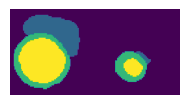

In [4]:
from utils.utils import show_samples

x1 = data_test[1].unsqueeze(0)
x2 = data_test[19].unsqueeze(0)

# Show masks
x = torch.cat([x1, x2], dim=0)
samples = torch.argmax(x, dim=1).unsqueeze(1)
show_samples(samples, rgb=False, ncol=2, figsize=(2, 4))

z1: 2.903437852859497
z2: 2.1400246620178223
torch.Size([10, 6])


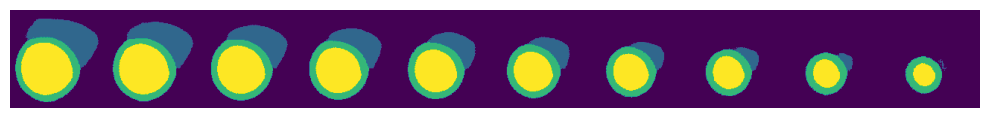

In [11]:
with torch.no_grad():
    model.eval()
    model.to(device)
    x1 = x1.to(device)
    x2 = x2.to(device)

    z1 = model.get_latent(x1, test=True)
    z2 = model.get_latent(x2, test=True)

    # Linear interpolation between z1 and z2
    z_lerps = []

    num_interpolations = 10

    for i in range(num_interpolations):
        z_lerps.append(
            torch.lerp(z1, z2, i / (num_interpolations - 1)).flatten()
        )

    z_lerps = torch.stack(z_lerps)

    print(z_lerps.shape)

    # Pass through decoder
    x_hat: torch.Tensor = model.decoder.net(z_lerps)

reconstructions = torch.argmax(x_hat, dim=1).unsqueeze(1)

show_samples(reconstructions, rgb=False, ncol=num_interpolations, figsize=(num_interpolations, 4))